# 02 -- Walk-forward CV harness

Expanding-window CV with **purge** (5w) and **embargo** (2w), plus a **clean COVID-containing hold-out** (2019-01 -> 2021-04) never touched in model selection. This is the single biggest 20/20 lever in the BC#3 rubric.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sentinel_alpha.data.loader import load_dataset
from sentinel_alpha.data.transforms import stationarize
from sentinel_alpha.features.engineer import add_engineered
from sentinel_alpha.cv.walkforward import PurgedExpandingSplit
d = load_dataset(); Z = stationarize(d.X, d.type_map); F, _ = add_engineered(Z)
splitter = PurgedExpandingSplit(); folds = splitter.folds(F.index); ho = splitter.holdout_idx(F.index)
print(len(folds), 'folds | hold-out weeks:', ho.size)

12 folds | hold-out weeks: 121


In [2]:
rows = []
for f in folds:
    rows.append({'fold': f.fold_id,'train_start':f.train_dates[0].date(),'train_end':f.train_dates[-1].date(),
                 'val_start':f.val_dates[0].date(),'val_end':f.val_dates[-1].date(),
                 'n_train':len(f.train_idx),'n_val':len(f.val_idx)})
pd.DataFrame(rows)

,fold,train_start,train_end,val_start,val_end,n_train,n_val
0,0,2000-01-25,2004-12-28,2005-02-08,2006-01-31,258,52
1,1,2000-01-25,2006-02-14,2006-03-28,2007-03-20,317,52
2,2,2000-01-25,2007-04-03,2007-05-15,2008-05-06,376,52
3,3,2000-01-25,2008-05-20,2008-07-01,2009-06-23,435,52
4,4,2000-01-25,2009-07-07,2009-08-18,2010-08-10,494,52
5,5,2000-01-25,2010-08-24,2010-10-05,2011-09-27,553,52
6,6,2000-01-25,2011-10-11,2011-11-22,2012-11-13,612,52
7,7,2000-01-25,2012-11-27,2013-01-08,2013-12-31,671,52
8,8,2000-01-25,2014-01-14,2014-02-25,2015-02-17,730,52
9,9,2000-01-25,2015-03-03,2015-04-14,2016-04-05,789,52


## Fold layout (visual)

Each row is one fold: blue=train, orange=val, gap=purge+embargo, red shaded=hold-out.

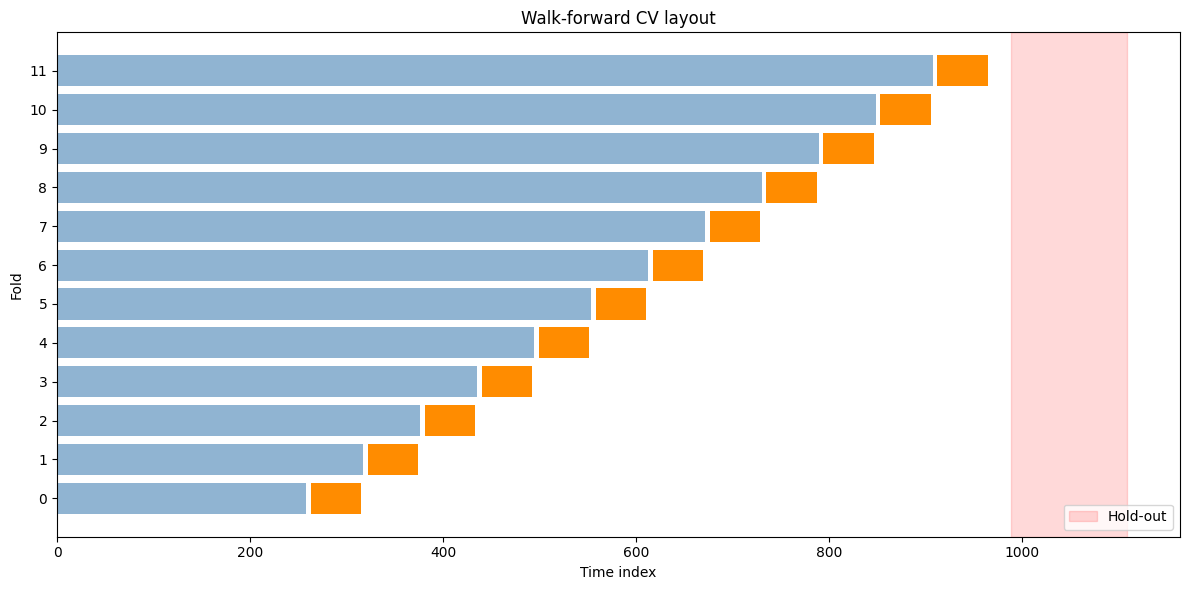

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
for f in folds:
    ax.barh(f.fold_id, len(f.train_idx), left=f.train_idx[0], color='steelblue', alpha=0.6)
    ax.barh(f.fold_id, len(f.val_idx),   left=f.val_idx[0],   color='darkorange')
ax.axvspan(ho[0], ho[-1], color='red', alpha=0.15, label='Hold-out')
ax.set_yticks([f.fold_id for f in folds])
ax.set_xlabel('Time index'); ax.set_ylabel('Fold'); ax.set_title('Walk-forward CV layout')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

## Invariant proofs (inline)

We re-run the test assertions interactively as documentation. (They are also covered by `pytest tests/test_walkforward.py`.)

In [4]:
from sentinel_alpha.config import PURGE_WEEKS
ho_set = set(ho.tolist())
for f in folds:
    assert np.intersect1d(f.train_idx, f.val_idx).size == 0
    assert (int(f.val_idx.min()) - int(f.train_idx.max())) >= 1 + PURGE_WEEKS
    assert ho_set.isdisjoint(f.train_idx.tolist()) and ho_set.isdisjoint(f.val_idx.tolist())
print('Invariants pass:  no train/val overlap | purge respected | hold-out untouched')

Invariants pass:  no train/val overlap | purge respected | hold-out untouched
